In [408]:
week = 12
function = 7

In [409]:
import pandas as pd
import numpy as np
import importlib

from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

In [410]:
import bbo_project.data_loading as data_loading
import bbo_project.data_augmentation as data_augmentation
import bbo_project.data_plotting as data_plotting

importlib.reload(data_loading)
importlib.reload(data_augmentation)
importlib.reload(data_plotting)

<module 'bbo_project.data_plotting' from 'C:\\Users\\gajones\\Desktop\\bbo_project\\src\\bbo_project\\data_plotting.py'>

In [411]:
print(f"Requested function {function} in week {week}")

print("\nData Loading")

# return path for required dataset
PROJECT_DIR, data_folder_name, week_folder_name = data_loading.get_working_week(week, function)

# load initial data
df = data_loading.load_initial_data(PROJECT_DIR, data_folder_name)
# print(f"\tloaded original data set...")

# Add updated points
df = data_loading.apply_updates(df, week, data_folder_name)

# create file structure for saving results to
results_dir = data_loading.create_results_dir(week_folder_name, data_folder_name)
print(f"\tresults will be saved to {results_dir}...")

print("\nData Preprocessing")
print("\tsetting values below numerical precision to zero")
df.loc[df["Y1"].abs() < 1e-6, "Y1"] = 0

print("\tscaling output variable")
Q3 = df["Y1"].quantile(0.75)
df["promising"] = (df["Y1"] >= Q3).astype(int)

print("\textracting input variables")
input_cols = data_loading.get_X_cols(df)

print("\tfinding points within threshold of current max")
df_fitting = data_augmentation.extract_distance_from_max(df, "Y1", input_cols, 12)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

df_fitting.loc[:, "YScaled"] = y_scaler.fit_transform(df_fitting[["Y1"]])
df_fitting.loc[:, input_cols] = x_scaler.fit_transform(df_fitting[input_cols])

print("\tseparating iputs and outputs for fitting")
X = df_fitting[input_cols].to_numpy(dtype=np.float32)
y = df_fitting["YScaled"].to_numpy(dtype=np.float32).reshape(-1,1)

print(f"\n Current Max Value: {df['Y1'].max()}")

Requested function 7 in week 12

Data Loading
	Loaded initial data: function_7
	Available update files:
		1: new_data_point_wk1.csv
		2: new_data_point_wk10.csv
		3: new_data_point_wk11.csv
		4: new_data_point_wk2.csv
		5: new_data_point_wk3.csv
		6: new_data_point_wk4.csv
		7: new_data_point_wk5.csv
		8: new_data_point_wk6.csv
		9: new_data_point_wk7.csv
		10: new_data_point_wk8.csv
		11: new_data_point_wk9.csv
	Added 11 new data points.
	results will be saved to c:\Users\gajones\Desktop\bbo_project\results\plots\week_12\function_7...

Data Preprocessing
	setting values below numerical precision to zero
	scaling output variable
	extracting input variables
	finding points within threshold of current max
	separating iputs and outputs for fitting

 Current Max Value: 2.214770856


C:\Users\gajones\AppData\Local\Temp\ipykernel_27868\1705593231.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fitting.loc[:, "YScaled"] = y_scaler.fit_transform(df_fitting[["Y1"]])


In [412]:
len(X)

15

In [ ]:
# =====================================================
# Hyperparameters
# =====================================================

n_hidden = 4
epochs = 10000
learning_rate = 0.01

lambda_reg = 1e-4      # L2 regularization strength
patience = 1000          # Early stopping patience

# =====================================================
# Train / Validation split
# =====================================================

# X_train, X_val, y_train, y_val = train_test_split(X,y,test_size=0.2,random_state=42)

from sklearn.model_selection import train_test_split

threshold = np.percentile(y_scaled, 75)

labels = (y_scaled.flatten() >= threshold).astype(int)

X_train, X_val, y_train, y_val = train_test_split(X_scaled,y_scaled,test_size=0.2,stratify=labels,random_state=42)

x_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

x_val = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_val = tf.convert_to_tensor(y_val, dtype=tf.float32)

n_features = X_train.shape[1]

# =====================================================
# Weight initialization
# =====================================================

W1 = tf.Variable(tf.random.normal(shape=(n_features + 1, n_hidden),stddev=np.sqrt(2 / n_features)))
W2 = tf.Variable(tf.random.normal(shape=(n_hidden, 1),stddev=np.sqrt(2 / n_hidden)))

# =====================================================
# Forward pass
# =====================================================

def forward_pass(x):

    bias = tf.ones((tf.shape(x)[0], 1))
    x = tf.concat([x, bias], axis=1)

    hidden = tf.matmul(x, W1)
    hidden = tf.nn.relu(hidden)

    output = tf.matmul(hidden, W2)

    return output

# =====================================================
# Loss / Optimizer
# =====================================================

mse_loss = tf.keras.losses.MeanSquaredError()
optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)

# =====================================================
# Training step
# =====================================================

@tf.function
def train_step(x, y):

    with tf.GradientTape() as tape:

        y_pred = forward_pass(x)

        mse = mse_loss(y, y_pred)

        l2_penalty = (tf.nn.l2_loss(W1)+ tf.nn.l2_loss(W2))

        loss = mse + lambda_reg * l2_penalty

    gradients = tape.gradient(loss, [W1, W2])

    optimizer.apply_gradients(zip(gradients, [W1, W2]))

    return loss

# =====================================================
# Validation step
# =====================================================

@tf.function
def validation_step(x, y):

    y_pred = forward_pass(x)

    mse = mse_loss(y, y_pred)

    l2_penalty = (tf.nn.l2_loss(W1)+ tf.nn.l2_loss(W2))

    loss = mse + lambda_reg * l2_penalty

    return loss

# =====================================================
# Training loop with Early Stopping
# =====================================================

train_loss_history = []
val_loss_history = []

best_val_loss = np.inf
best_W1 = None
best_W2 = None

epochs_without_improvement = 0

for epoch in range(epochs):

    train_loss = train_step(x_train, y_train)

    val_loss = validation_step(x_val, y_val)

    train_loss_history.append(train_loss.numpy())
    val_loss_history.append(val_loss.numpy())

    if val_loss < best_val_loss:

        best_val_loss = val_loss.numpy()

        best_W1 = W1.numpy().copy()
        best_W2 = W2.numpy().copy()

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epoch % 50 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Train Loss = {train_loss:.6f} | "
            f"Validation Loss = {val_loss:.6f}"
        )

    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch}")

        break

# =====================================================
# Restore best weights
# =====================================================

W1.assign(best_W1)
W2.assign(best_W2)

print(f"\nBest validation loss = {best_val_loss:.6f}")


Epoch     0 | Train Loss = 2.520653 | Validation Loss = 2.197573
Epoch    50 | Train Loss = 0.654892 | Validation Loss = 0.158775
Epoch   100 | Train Loss = 0.596068 | Validation Loss = 0.077393
Epoch   150 | Train Loss = 0.552930 | Validation Loss = 0.035634
Epoch   200 | Train Loss = 0.515222 | Validation Loss = 0.012963
Epoch   250 | Train Loss = 0.482161 | Validation Loss = 0.002904
Epoch   300 | Train Loss = 0.453024 | Validation Loss = 0.001650
Epoch   350 | Train Loss = 0.426938 | Validation Loss = 0.006676
Epoch   400 | Train Loss = 0.403128 | Validation Loss = 0.015956
Epoch   450 | Train Loss = 0.380882 | Validation Loss = 0.028228
Epoch   500 | Train Loss = 0.358854 | Validation Loss = 0.043372
Epoch   550 | Train Loss = 0.336151 | Validation Loss = 0.059439
Epoch   600 | Train Loss = 0.312450 | Validation Loss = 0.073427
Epoch   650 | Train Loss = 0.286593 | Validation Loss = 0.086957
Epoch   700 | Train Loss = 0.259191 | Validation Loss = 0.103348
Epoch   750 | Train Loss 

RMSE = 0.018709


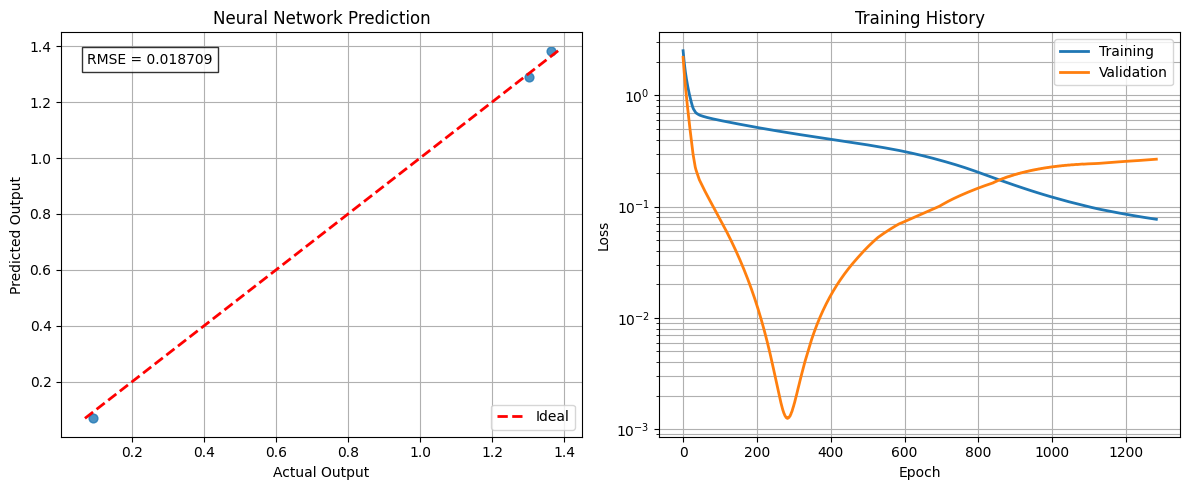

In [414]:
# =====================================================
# Predict on all data (scaled inputs)
# =====================================================

# x_all = tf.convert_to_tensor(X, dtype=tf.float32)
# y_pred_scaled = forward_pass(x_all).numpy()

x_val_tf = tf.convert_to_tensor(X_val, dtype=tf.float32)
y_pred_scaled = forward_pass(x_val_tf).numpy()


# =====================================================
# Convert back to original units
# =====================================================

y_pred = y_scaler.inverse_transform(y_pred_scaled)

y_true = y_scaler.inverse_transform(y_val)

# =====================================================
# Calculate RMSE in original units
# =====================================================

rmse = np.sqrt(np.mean((y_true - y_pred)**2))

print(f"RMSE = {rmse:.6f}")

# =====================================================
# Plot results
# =====================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# -----------------------------------------------------
# Actual vs Predicted (Original Scale)
# -----------------------------------------------------

ax1.scatter(
    y_true.flatten(),
    y_pred.flatten(),
    s=40,
    alpha=0.8
)

lims = [
    min(y_true.min(), y_pred.min()),
    max(y_true.max(), y_pred.max())
]

ax1.plot(
    lims,
    lims,
    "r--",
    linewidth=2,
    label="Ideal"
)

# ax1.set_xlim(lims)
# ax1.set_ylim(lims)

ax1.set_xlabel("Actual Output")
ax1.set_ylabel("Predicted Output")
ax1.set_title("Neural Network Prediction")
ax1.grid(True)
ax1.legend()

# Display RMSE on the plot
ax1.text(
    0.05,
    0.95,
    f"RMSE = {rmse:.6f}",
    transform=ax1.transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.8)
)

# -----------------------------------------------------
# Training History
# -----------------------------------------------------

ax2.plot(
    train_loss_history,
    label="Training",
    linewidth=2
)

ax2.plot(
    val_loss_history,
    label="Validation",
    linewidth=2
)

ax2.set_yscale("log")

ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.set_title("Training History")

ax2.grid(True, which="both")
ax2.legend()

plt.tight_layout()
plt.show()

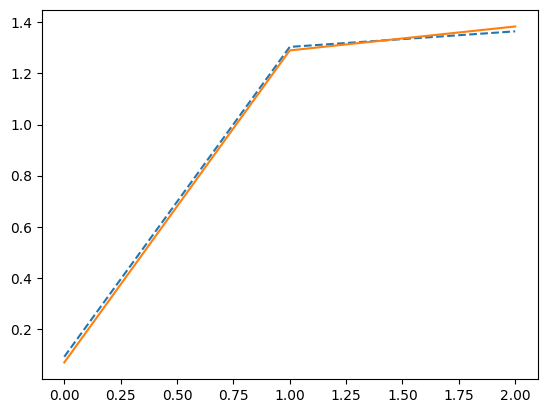

In [415]:

x_val_tf = tf.convert_to_tensor(x_val, dtype=tf.float32)
y_pred_scaled = forward_pass(x_val_tf).numpy()

y_pred = y_scaler.inverse_transform(y_pred_scaled)
y_true = y_scaler.inverse_transform(y_val)

plt.plot(range(len(y_true)),y_true,'--')
plt.plot(range(len(y_pred)),y_pred)


In [416]:
print(f"Calaculating Convex Hull around chosen data set...")
hull, points_hull = data_augmentation.compute_convex_hull(df_fitting[input_cols])
internal_points = data_augmentation.seed_convex_hull(points_hull, hull)

y_test = forward_pass(internal_points).numpy()

# y_pred_scaled = forward_pass(x_all).numpy()

best_index = np.argmax(y_test)

x_max = internal_points[best_index]
y_max = y_test[best_index]

# undo scaling
x_max_original = x_scaler.inverse_transform(
    x_max.reshape(1, -1)
)

y_max_original = y_scaler.inverse_transform(
    y_max.reshape(1, -1)
)

print("Maximum location:")
print(x_max_original)

print("Maximum value:")
print(y_max_original,df["Y1"].max())

Calaculating Convex Hull around chosen data set...
Maximum location:
[[0.15998636 0.59071268 0.3095158  0.39503312 0.19849901 0.72197903]]
Maximum value:
[[1.4965439]] 2.214770856


(<Figure size 1500x250 with 6 Axes>,
 array([[<Axes: xlabel='X1', ylabel='YScaled'>, <Axes: xlabel='X2'>,
         <Axes: xlabel='X3'>, <Axes: xlabel='X4'>, <Axes: xlabel='X5'>,
         <Axes: xlabel='X6'>]], dtype=object))

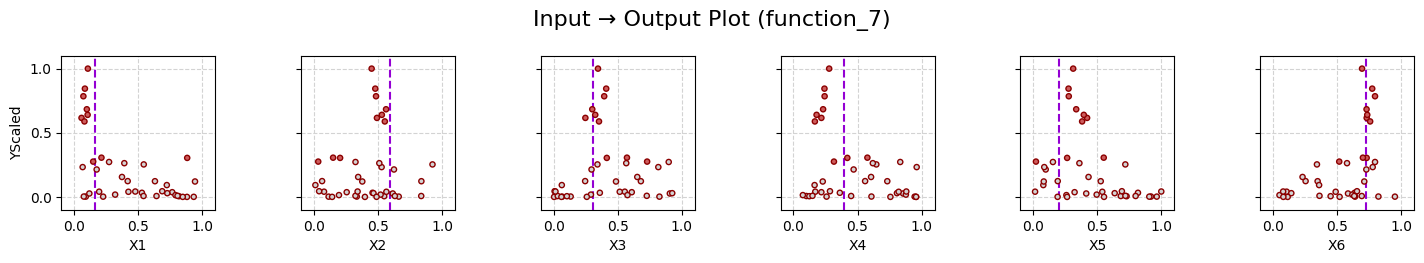

In [417]:
best_point_dict = {col: val for col, val in zip(input_cols, x_max_original[0])}

X = df[input_cols].to_numpy()

df["YScaled"] = data_augmentation.minmax_scale(df["Y1"])
Y = df["YScaled"].to_numpy()
Y = np.asarray(Y).reshape(-1, 1)

try:
    Z = df["promising"].to_numpy().reshape(-1, 1)
except:
    Z = np.zeros(len(Y)) 

data_plotting.domain_io_plot(data_folder_name, results_dir, input_cols, ["YScaled"], X, Y, Z, next_point=best_point_dict)

In [418]:
s = "-".join(f"{v:.6f}" for v in best_point_dict.values())
print(s)

0.159986-0.590713-0.309516-0.395033-0.198499-0.721979
